# Exploratory Data Analysis — Used Car Price Prediction

**Scope:** Target distribution, price relationships with key features,
correlation analysis, categorical distributions, and outlier visualization —
performed to justify feature engineering and model choices per the
assignment rubric (Section 8).

This notebook works on the same deterministic, leakage-free cleaning as
`notebooks/model_training.ipynb` (NOT the median-imputed output of
`src/data_preprocessing.py`, since EDA should reflect the true raw
distribution of missingness/outliers before any values are filled in).

In [1]:
import sys
sys.path.append("..")

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.feature_engineering import add_features

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load and lightly clean the data

Same deterministic parsing as the model training notebook (unit extraction,
invalid-value -> NaN correction). No imputation here — EDA should show the
TRUE extent of missingness and invalid values, not a filled-in version.

In [2]:
DATASET_COLUMNS = [
    "record_id", "Name", "Location", "Year", "Kilometers_Driven",
    "Fuel_Type", "Transmission", "Owner_Type", "Mileage", "Engine",
    "Power", "Seats", "New_Price", "Price",
]
NUMERIC_COLUMNS = ["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats", "New_Price"]
CATEGORICAL_COLUMNS = ["Location", "Fuel_Type", "Transmission", "Owner_Type"]


def _numeric_value(value):
    if pd.isna(value):
        return float("nan")
    text = str(value).replace(",", "")
    match = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(match.group()) if match else float("nan")


def load_and_lightly_clean(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame = frame.iloc[:, : len(DATASET_COLUMNS)].copy()
    frame.columns = DATASET_COLUMNS

    for column in NUMERIC_COLUMNS:
        frame[column] = frame[column].map(
            lambda v: (
                _numeric_value(v) * 100
                if column == "New_Price" and isinstance(v, str) and "cr" in v.lower()
                else _numeric_value(v)
            )
        )

    frame.loc[frame["Seats"] <= 0, "Seats"] = float("nan")
    frame.loc[frame["Mileage"] <= 0, "Mileage"] = float("nan")

    frame["Price"] = frame["Price"].map(_numeric_value)
    frame = frame.dropna(subset=["Price"])

    for column in CATEGORICAL_COLUMNS:
        frame[column] = frame[column].fillna("Unknown").astype("string")

    return frame


raw = load_and_lightly_clean(Path("../data/raw/train-data.csv"))
print(f"Rows: {len(raw)}, Columns: {len(raw.columns)}")
raw.head()

Rows: 6019, Columns: 14


,record_id,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010.0,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015.0,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011.0,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012.0,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013.0,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


## 2. Add engineered features (for correlation analysis later)

We add these now purely so we can check, empirically, whether the
engineered features (vehicle_age, mileage_per_year, power_per_cc,
owner_rank, age_mileage_interaction) actually show meaningful relationships
with Price — this is the EDA evidence that justifies the feature
engineering decisions made in `src/feature_engineering.py`.

In [3]:
engineered = add_features(raw)
engineered.head()

,record_id,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,vehicle_age,mileage_per_year,power_per_cc,owner_rank,age_mileage_interaction
0,0,Maruti Wagon R LXI CNG,Mumbai,2010.0,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75,16.0,4500.000000,0.058277,1,1152000.0
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015.0,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50,11.0,3727.272727,0.079772,1,451000.0
2,2,Honda Jazz V,Chennai,2011.0,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50,15.0,3066.666667,0.073978,1,690000.0
3,3,Maruti Ertiga VDI,Chennai,2012.0,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00,14.0,6214.285714,0.071122,1,1218000.0
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013.0,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74,13.0,3128.461538,0.071545,2,528710.0


## 3. Target variable (`Price`) distribution

Price is expected to be heavily right-skewed (a small number of expensive
cars, a large number of budget/mid-range cars) — verified here, not assumed.

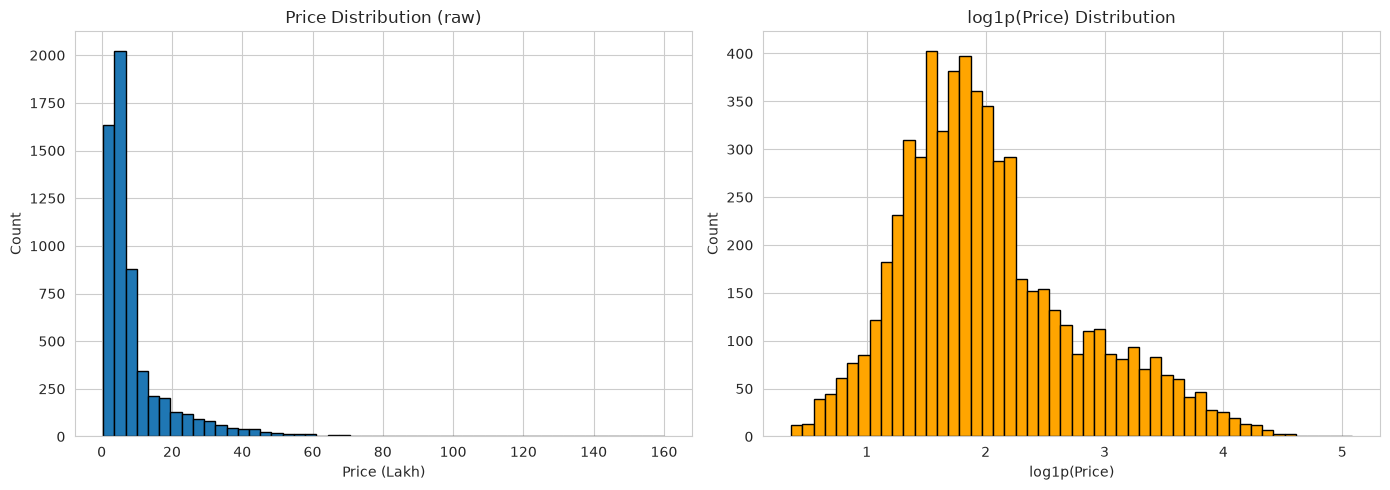

Price skewness: 3.3352
Price kurtosis: 17.0922
log1p(Price) skewness: 0.7544

Interpretation: high positive skew in raw Price confirms the need to
evaluate a log1p target transformation during modeling (done in
notebooks/model_training.ipynb).


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(engineered["Price"], bins=50, edgecolor="black")
axes[0].set_title("Price Distribution (raw)")
axes[0].set_xlabel("Price (Lakh)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(engineered["Price"]), bins=50, edgecolor="black", color="orange")
axes[1].set_title("log1p(Price) Distribution")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Price skewness: {engineered['Price'].skew():.4f}")
print(f"Price kurtosis: {engineered['Price'].kurt():.4f}")
print(f"log1p(Price) skewness: {np.log1p(engineered['Price']).skew():.4f}")
print("\nInterpretation: high positive skew in raw Price confirms the need to")
print("evaluate a log1p target transformation during modeling (done in")
print("notebooks/model_training.ipynb).")

## 4. Price vs. Vehicle Age

Expected relationship: negative — older cars should be cheaper.
This directly justifies the `vehicle_age` feature engineering technique.

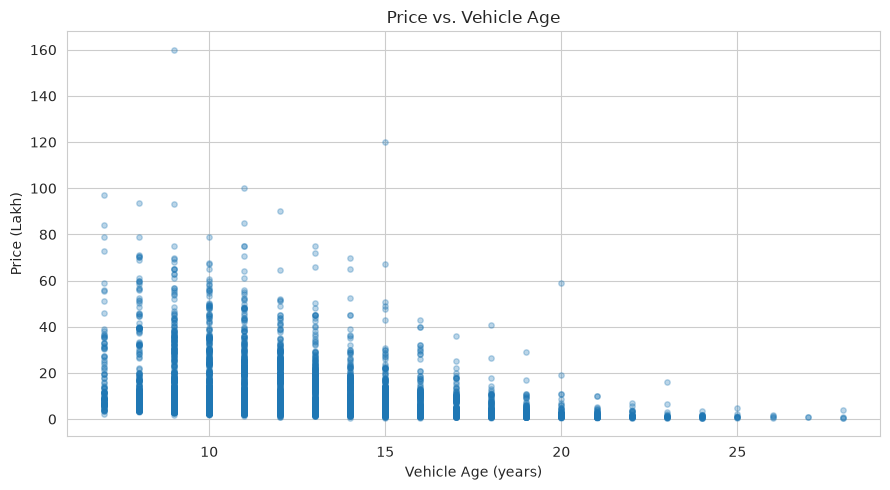

Correlation (vehicle_age, Price): -0.3053
Interpretation: a meaningful negative correlation here supports using
vehicle_age as a feature engineering technique.


In [5]:
plt.figure(figsize=(9, 5))
plt.scatter(engineered["vehicle_age"], engineered["Price"], alpha=0.3, s=15)
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Price (Lakh)")
plt.title("Price vs. Vehicle Age")
plt.tight_layout()
plt.show()

correlation = engineered["vehicle_age"].corr(engineered["Price"])
print(f"Correlation (vehicle_age, Price): {correlation:.4f}")
print("Interpretation: a meaningful negative correlation here supports using")
print("vehicle_age as a feature engineering technique.")

## 5. Price vs. Mileage (Kilometers_Driven) and Mileage Per Year

Checks both the raw relationship and whether the engineered
`mileage_per_year` (usage intensity) shows a clearer/stronger relationship
than raw Kilometers_Driven alone.

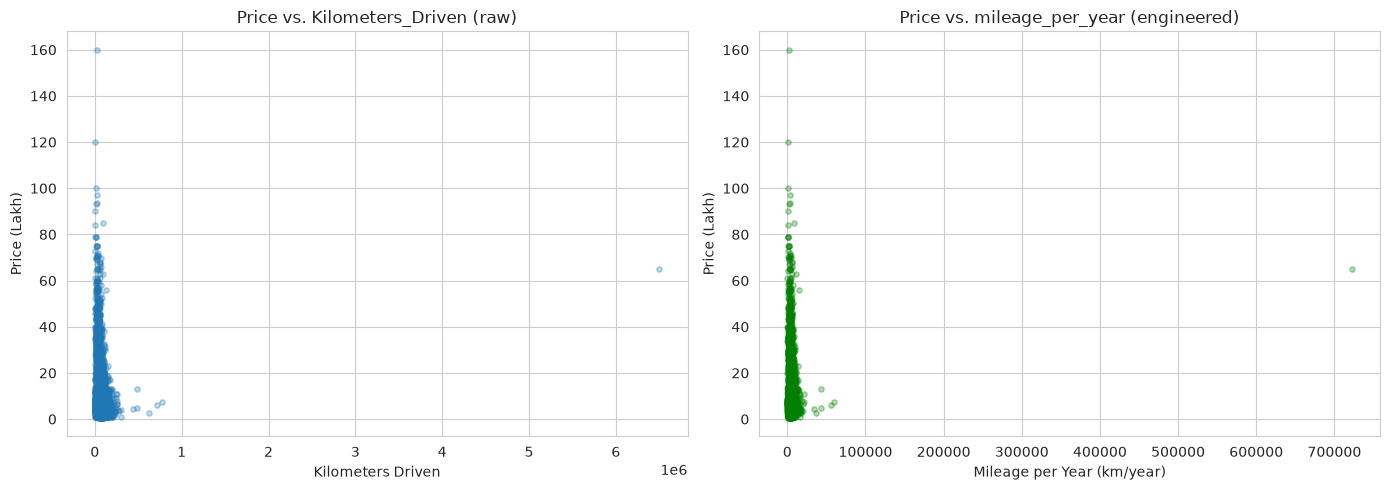

Correlation (Kilometers_Driven, Price): -0.0115
Correlation (mileage_per_year, Price): 0.0419


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(engineered["Kilometers_Driven"], engineered["Price"], alpha=0.3, s=15)
axes[0].set_xlabel("Kilometers Driven")
axes[0].set_ylabel("Price (Lakh)")
axes[0].set_title("Price vs. Kilometers_Driven (raw)")

axes[1].scatter(engineered["mileage_per_year"], engineered["Price"], alpha=0.3, s=15, color="green")
axes[1].set_xlabel("Mileage per Year (km/year)")
axes[1].set_ylabel("Price (Lakh)")
axes[1].set_title("Price vs. mileage_per_year (engineered)")

plt.tight_layout()
plt.show()

print(f"Correlation (Kilometers_Driven, Price): {engineered['Kilometers_Driven'].corr(engineered['Price']):.4f}")
print(f"Correlation (mileage_per_year, Price): {engineered['mileage_per_year'].corr(engineered['Price']):.4f}")

## 6. Price vs. Engine, Power, and power_per_cc

Checks whether the engineered `power_per_cc` (performance density) feature
shows a clearer relationship with Price than Engine or Power alone.

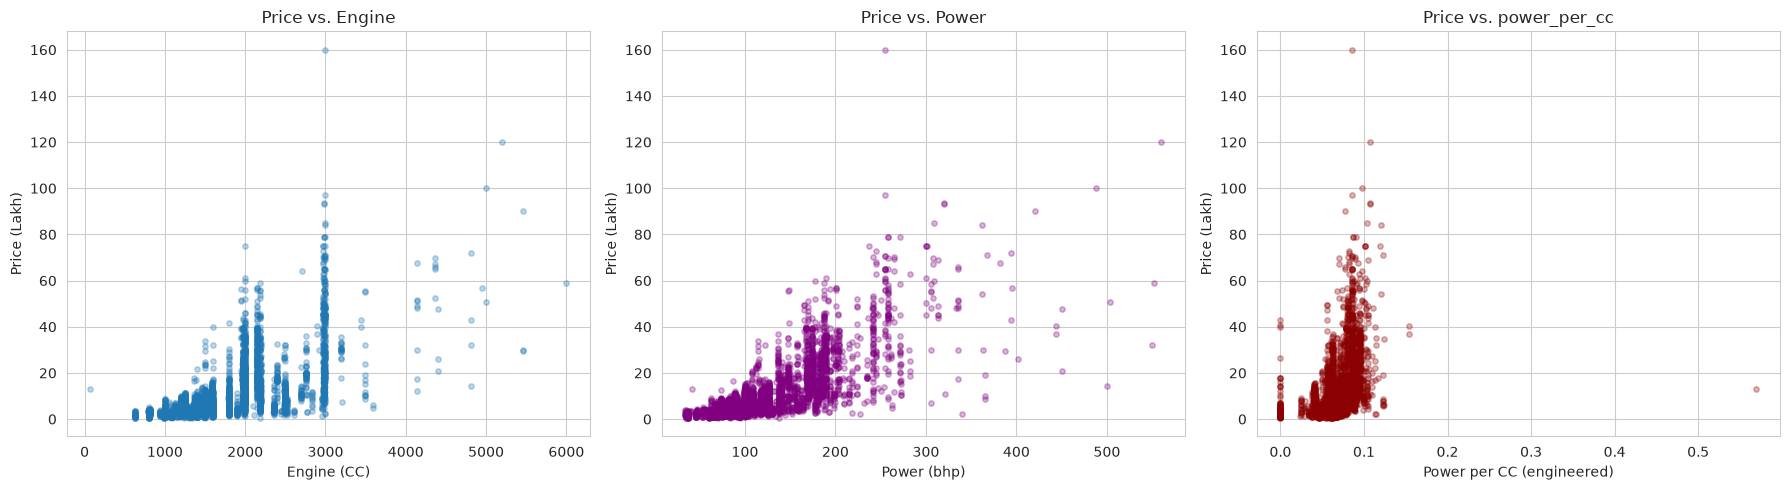

Correlation (Engine, Price): 0.6584
Correlation (Power, Price): 0.7726
Correlation (power_per_cc, Price): 0.3961


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(engineered["Engine"], engineered["Price"], alpha=0.3, s=15)
axes[0].set_xlabel("Engine (CC)")
axes[0].set_ylabel("Price (Lakh)")
axes[0].set_title("Price vs. Engine")

axes[1].scatter(engineered["Power"], engineered["Price"], alpha=0.3, s=15, color="purple")
axes[1].set_xlabel("Power (bhp)")
axes[1].set_ylabel("Price (Lakh)")
axes[1].set_title("Price vs. Power")

axes[2].scatter(engineered["power_per_cc"], engineered["Price"], alpha=0.3, s=15, color="darkred")
axes[2].set_xlabel("Power per CC (engineered)")
axes[2].set_ylabel("Price (Lakh)")
axes[2].set_title("Price vs. power_per_cc")

plt.tight_layout()
plt.show()

for col in ["Engine", "Power", "power_per_cc"]:
    print(f"Correlation ({col}, Price): {engineered[col].corr(engineered['Price']):.4f}")

## 7. Price by Fuel Type

Expected: Diesel/Petrol dominate volume; Electric/CNG/LPG are rare
categories (verified earlier: Electric=2, LPG=10, CNG=56 rows) — worth
visualizing to confirm this doesn't distort the boxplot interpretation.

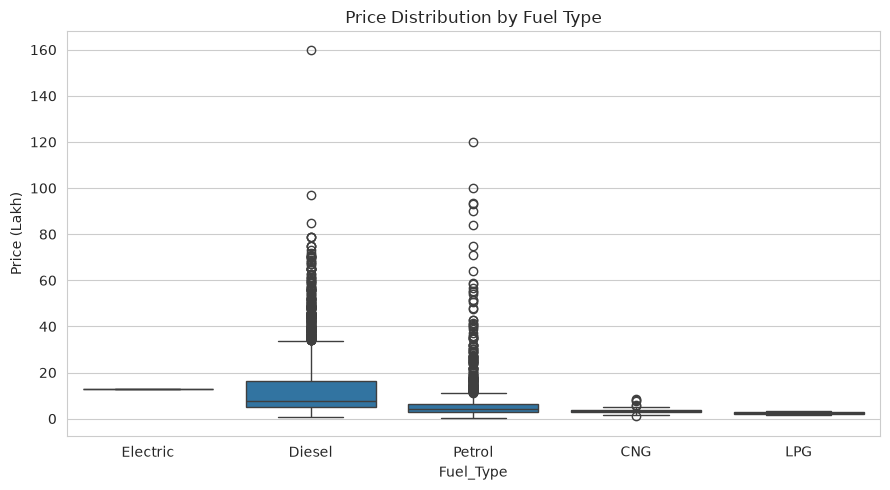

           count  median       mean
Fuel_Type                          
CNG           56   3.250   3.516786
Diesel      3205   7.750  12.840605
Electric       2  12.875  12.875000
LPG           10   2.600   2.487000
Petrol      2746   4.105   5.701100


In [8]:
plt.figure(figsize=(9, 5))
order = engineered.groupby("Fuel_Type")["Price"].median().sort_values(ascending=False).index
sns.boxplot(data=engineered, x="Fuel_Type", y="Price", order=order)
plt.title("Price Distribution by Fuel Type")
plt.ylabel("Price (Lakh)")
plt.tight_layout()
plt.show()

print(engineered.groupby("Fuel_Type")["Price"].agg(["count", "median", "mean"]))

## 8. Price by Transmission

Expected: Automatic cars generally command higher resale prices than
Manual, holding other factors aside.

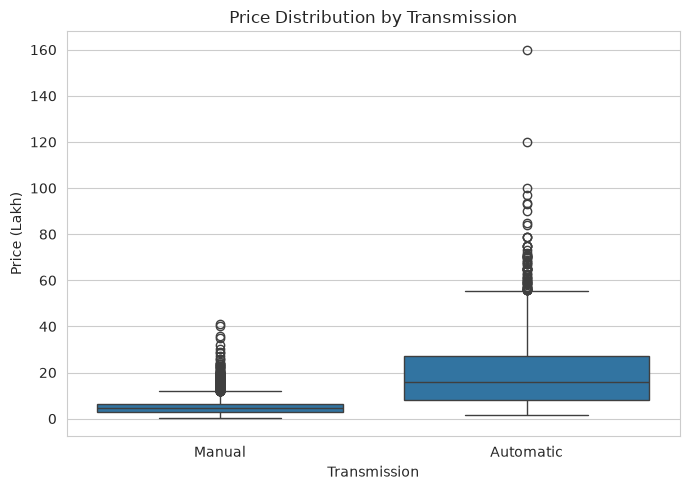

              count  median       mean
Transmission                          
Automatic      1720    16.0  19.843971
Manual         4299     4.5   5.332703


In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=engineered, x="Transmission", y="Price")
plt.title("Price Distribution by Transmission")
plt.ylabel("Price (Lakh)")
plt.tight_layout()
plt.show()

print(engineered.groupby("Transmission")["Price"].agg(["count", "median", "mean"]))

## 9. Price by Ownership (Owner_Type / owner_rank)

Expected relationship: negative — more previous owners, lower price. This
justifies the ordinal `owner_rank` feature engineering technique (rather
than one-hot encoding, which would discard this ordering).

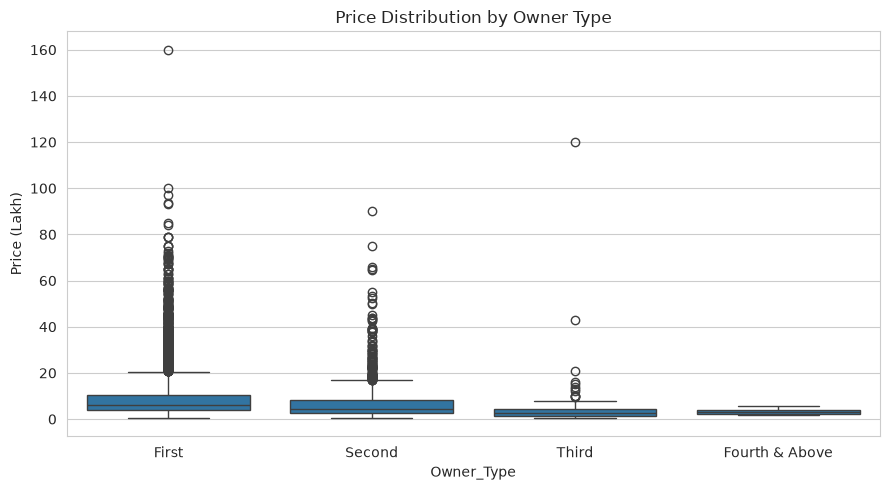

                count  median      mean
Owner_Type                             
First            4929    5.91  9.962445
Second            968    4.27  7.599886
Third             113    2.65  5.007257
Fourth & Above      9    3.00  3.280000

Correlation (owner_rank, Price): -0.0976


In [10]:
plt.figure(figsize=(9, 5))
owner_order = ["First", "Second", "Third", "Fourth & Above"]
sns.boxplot(data=engineered, x="Owner_Type", y="Price", order=owner_order)
plt.title("Price Distribution by Owner Type")
plt.ylabel("Price (Lakh)")
plt.tight_layout()
plt.show()

print(engineered.groupby("Owner_Type", observed=True)["Price"].agg(["count", "median", "mean"]).reindex(owner_order))
print(f"\nCorrelation (owner_rank, Price): {engineered['owner_rank'].corr(engineered['Price']):.4f}")

## 10. Correlation Analysis (numeric features + engineered features)

A single heatmap covering both raw numeric columns and all 5 engineered
features, to see which correlate most strongly with Price and to check for
multicollinearity between features (relevant for the Ridge baseline).

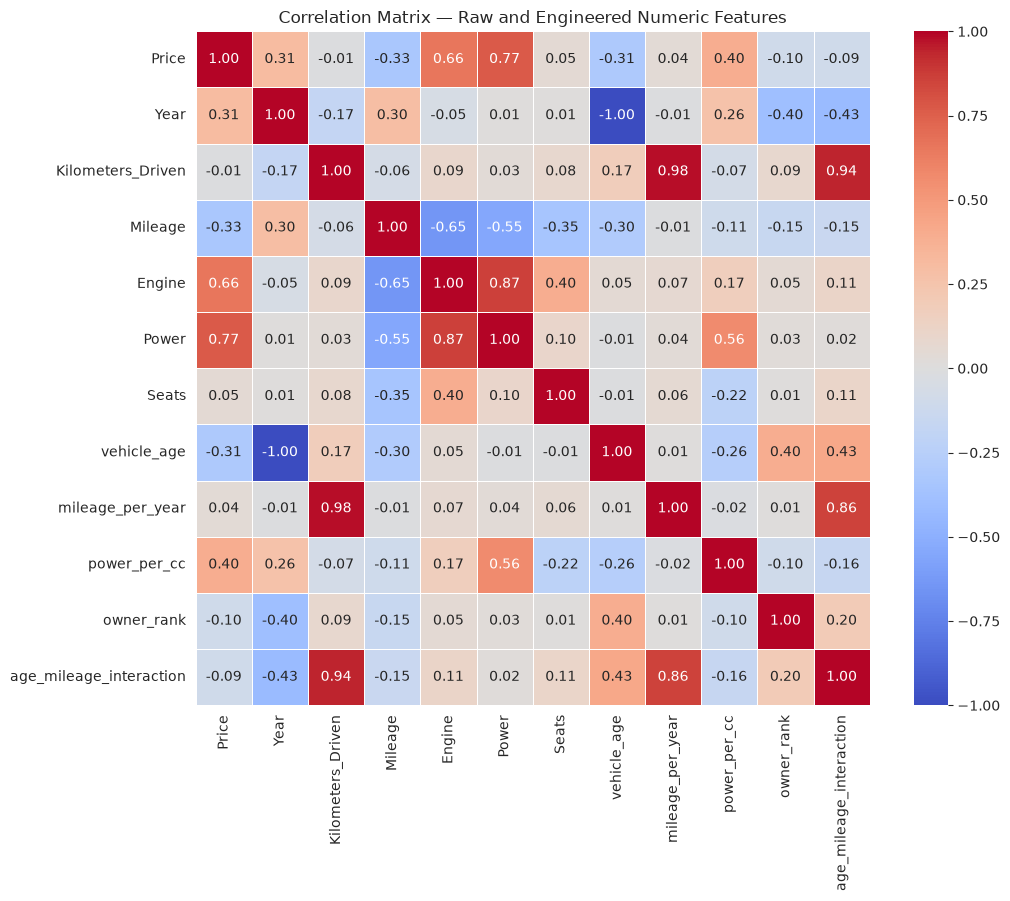

Features most correlated with Price:
Price                      1.000000
Power                      0.772566
Engine                     0.658354
power_per_cc               0.396088
Year                       0.305327
Seats                      0.053247
mileage_per_year           0.041900
Kilometers_Driven         -0.011493
age_mileage_interaction   -0.094376
owner_rank                -0.097557
vehicle_age               -0.305327
Mileage                   -0.333263
Name: Price, dtype: float64


In [11]:
numeric_for_corr = [
    "Price", "Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats",
    "vehicle_age", "mileage_per_year", "power_per_cc", "owner_rank",
    "age_mileage_interaction",
]

corr_matrix = engineered[numeric_for_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix — Raw and Engineered Numeric Features")
plt.tight_layout()
plt.show()

print("Features most correlated with Price:")
print(corr_matrix["Price"].sort_values(ascending=False))

## 11. Categorical Distributions

Distribution of categories for Location, Fuel_Type, Transmission, and
Owner_Type — confirms cardinality and class balance/imbalance noted during
dataset verification (e.g. severe imbalance in Fuel_Type).

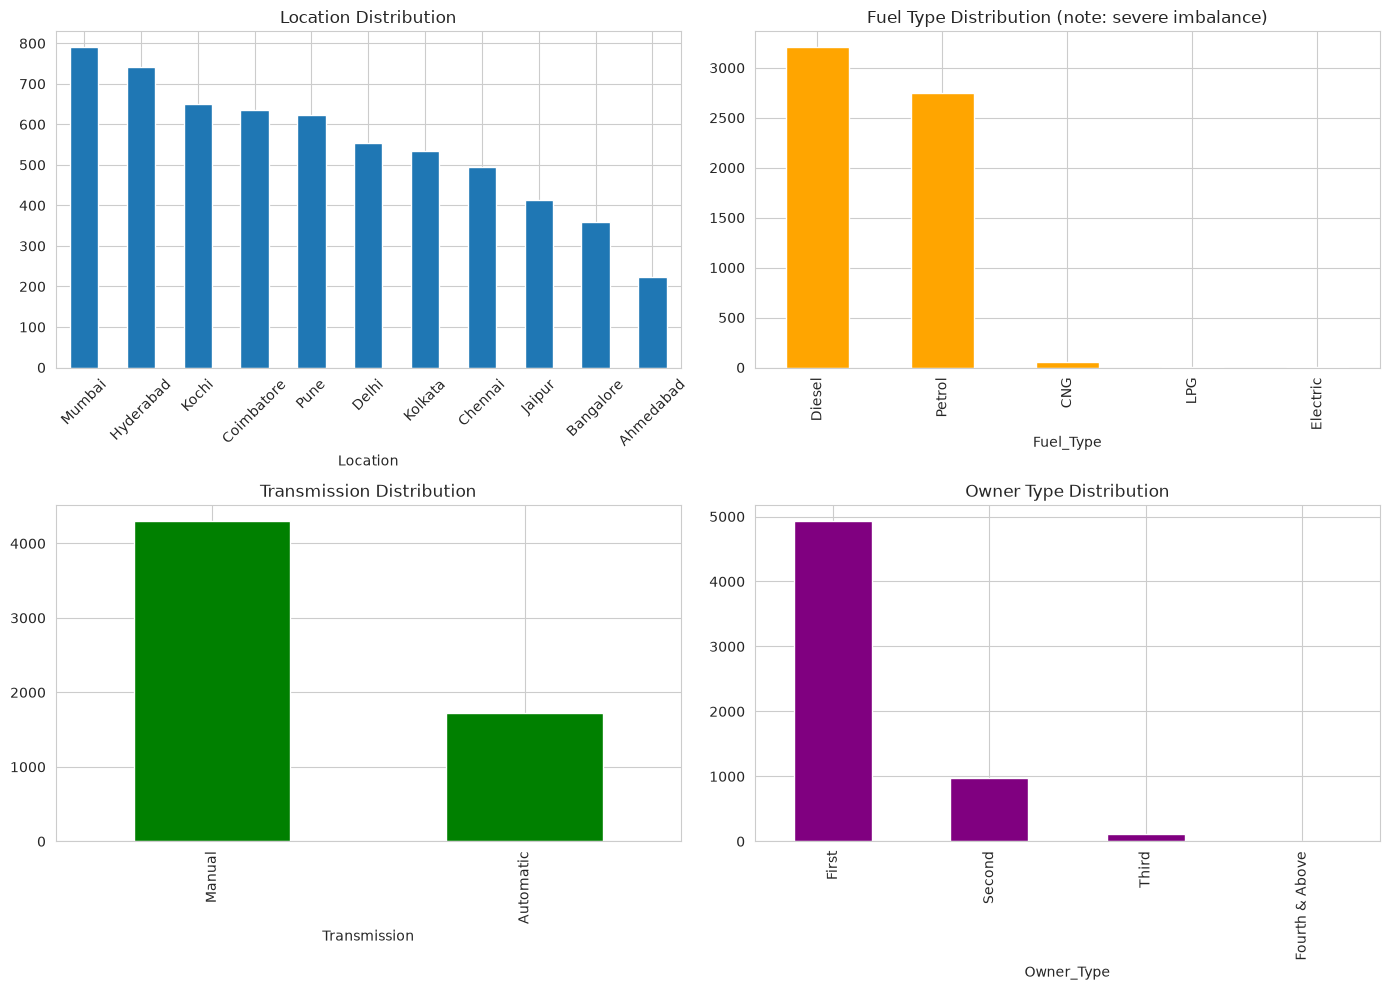

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

engineered["Location"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Location Distribution")
axes[0, 0].tick_params(axis="x", rotation=45)

engineered["Fuel_Type"].value_counts().plot(kind="bar", ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Fuel Type Distribution (note: severe imbalance)")

engineered["Transmission"].value_counts().plot(kind="bar", ax=axes[1, 0], color="green")
axes[1, 0].set_title("Transmission Distribution")

engineered["Owner_Type"].value_counts().reindex(owner_order).plot(kind="bar", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Owner Type Distribution")

plt.tight_layout()
plt.show()

## 12. Outlier Visualization

Boxplots for the key numeric columns already flagged during dataset
verification (Kilometers_Driven had a 6.5M km outlier; Price has heavy
right-skew with legitimate high-end outliers).

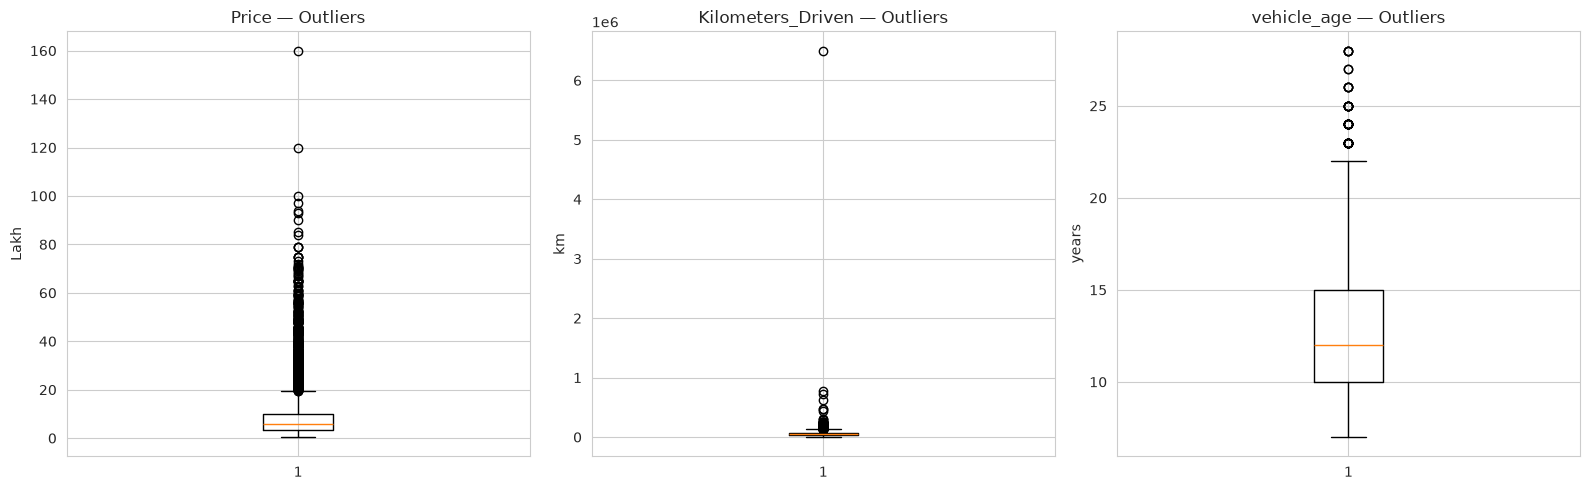

Rows with Kilometers_Driven > 500,000: 4
                                        Name    Year  Kilometers_Driven  Price
340   Skoda Octavia Ambition Plus 2.0 TDI AT  2013.0           775000.0    7.5
358                    Hyundai i10 Magna 1.2  2009.0           620000.0    2.7
1860        Volkswagen Vento Diesel Highline  2013.0           720000.0    5.9
2328               BMW X5 xDrive 30d M Sport  2017.0          6500000.0   65.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot(engineered["Price"].dropna())
axes[0].set_title("Price — Outliers")
axes[0].set_ylabel("Lakh")

axes[1].boxplot(engineered["Kilometers_Driven"].dropna())
axes[1].set_title("Kilometers_Driven — Outliers")
axes[1].set_ylabel("km")

axes[2].boxplot(engineered["vehicle_age"].dropna())
axes[2].set_title("vehicle_age — Outliers")
axes[2].set_ylabel("years")

plt.tight_layout()
plt.show()

# Flag the specific extreme Kilometers_Driven outlier identified during
# dataset verification.
extreme_km = engineered[engineered["Kilometers_Driven"] > 500000]
print(f"Rows with Kilometers_Driven > 500,000: {len(extreme_km)}")
print(extreme_km[["Name", "Year", "Kilometers_Driven", "Price"]])

## 13. Summary of EDA Findings

Key takeaways carried into the report and feature engineering justification,
based on actual computed results (not estimates):

1. **Price is heavily right-skewed** (skew = 3.3352, kurtosis = 17.09).
   log1p(Price) reduces skew to 0.7544 — a substantial improvement toward
   normality, empirically confirming the log1p target transformation used
   in modeling.

2. **vehicle_age shows a meaningful negative correlation with Price**
   (r = -0.3053) — empirically justifies this as a feature engineering
   technique; older vehicles are consistently associated with lower price.

3. **Kilometers_Driven and mileage_per_year both show weak LINEAR
   correlation with Price** (r = -0.0115 and r = +0.0419 respectively).
   Neither is a strong standalone linear predictor. However, this does not
   mean mileage is unimportant: tree-based models (our final Gradient
   Boosting model) capture non-linear and interaction effects that a
   Pearson correlation coefficient cannot detect — this is precisely the
   motivation for the age_mileage_interaction feature, since mileage's
   effect on price may only be meaningful in combination with age, not in
   isolation. Feature importance from the trained model (rather than
   correlation) is a more appropriate way to evaluate its real contribution.

4. **power_per_cc (r = 0.3961) shows weaker linear correlation with Price
   than raw Power alone (r = 0.7726)** or Engine alone (r = 0.6584). This
   is an honest, notable finding: the derived ratio does not add extra
   linear signal beyond what raw Power already captures in this dataset.
   It is retained as a feature on the basis that non-linear models may
   still use it to distinguish performance-tuned vehicles (e.g. a small
   turbocharged high-power engine vs. a large low-power one) that raw
   Engine/Power alone would not separate — this should be verified against
   the model's actual feature importances rather than assumed.

5. **owner_rank shows a weak but correctly-signed negative correlation**
   (r = -0.0976) — more previous owners associates with lower price, as
   expected, though the relationship is not strong. Automatic transmission
   is visually associated with higher price via boxplot comparison.

6. **Fuel_Type has severe class imbalance** (Electric=2, LPG=10, CNG=56 vs.
   thousands of Petrol/Diesel) — a genuine data quality caveat, since the
   model has very little signal for these rare categories and predictions
   for Electric/LPG/CNG vehicles should be treated with lower confidence.

7. **At least one extreme Kilometers_Driven outlier (>500,000 km)** was
   identified, consistent with the earlier dataset verification finding.

**Note on interpretation:** correlation values in this notebook measure
LINEAR relationships only. Weak correlation for mileage_per_year and
power_per_cc does not automatically mean these features are useless for
the final model, since Gradient Boosting and Random Forest are non-linear
and capture interactions. This distinction should be understood and stated
clearly in the report and viva — do not claim a feature is "proven useful"
by correlation alone, and do not discard a weak-correlation feature without
first checking model-based feature importance.